In [1]:
!nvidia-smi
!lscpu
!free -h
!cat /etc/os-release
!df -h

Sat Aug 15 01:35:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
SEED = 42
BATCH_SIZE = 256
LR = 1e-3
WEIGHT_DECAY = 0.05
FL_GAMMA = 2.0
NUM_WORKERS = 3

In [3]:
import os
import gc
import sys
import json
import time
import copy
import h5py
import random
import logging
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
from typing import Dict, Any, Optional, List, Tuple
from sklearn.metrics import f1_score, precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datetime import datetime
from scipy.stats import spearmanr
from scipy.ndimage import label, binary_dilation, binary_erosion

import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, TensorDataset, DataLoader
torch.set_float32_matmul_precision('medium')

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pytorch_lightning.loggers import CSVLogger

import torchmetrics
from torchmetrics.classification import (
    MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    BinaryF1Score, BinaryAccuracy, BinaryPrecision, BinaryRecall
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

from kaggle_secrets import UserSecretsClient
webhook_url = UserSecretsClient().get_secret("DISCORD_WEBHOOK")

!pip freeze > requirements.txt

def setup_logger(output_dir: str = None) -> logging.Logger:
    """
    Configures and returns a structured logger for experiment tracking.
    Outputs to stdout and optionally logs to a text file in output_dir.
    """
    logger = logging.getLogger("experiment")
    logger.setLevel(logging.INFO)
    
    # Prevent duplicate logs if handler is already attached
    if logger.hasHandlers():
        logger.handlers.clear()

    # Define standard log format
    formatter = logging.Formatter(
        fmt="[%(asctime)s] [%(levelname)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Console Handler (stdout)
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    # File Handler (optional: saves log output directly to experiment directory)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        file_handler = logging.FileHandler(f"{output_dir}/experiment.log")
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger

def dispatch_discord_notification(
    summary: Dict[str, Any]
) -> None:
    """
    Accepts experiment output dictionary, formats message payload, and posts to Discord via Kaggle Secrets.
    """
    logger = logging.getLogger("experiment")
    

    # Build metric summary lines
    metric_lines = [
        f"• **{metric}**: `{data['mean']:.4f} ± {data['std']:.4f}`"
        for metric, data in summary["cv_summary"].items()
    ]
    metrics_block = "\n".join(metric_lines)
    
    ratio_str = f"`{summary['undersample_ratio']}`" if summary['undersample_ratio'] is not None else "`N/A`"

    message = (
        f"**Training Pipeline Execution Complete**\n\n"
        f"**Experiment Configuration:**\n"
        f"• **Dataset:** `{summary['dataset_name']}`\n"
        f"• **Patch Size:** `{summary['resolution']}x{summary['resolution']} px`\n"
        f"• **Model:** `{summary['model_name']}`\n"
        f"• **Experiment Type:** `{summary['experiment_type'].upper()}`\n"
        f"• **Undersample Ratio:** {ratio_str}\n"
        f"• **Total Execution Time:** `{summary['execution_time']}`\n\n"
        f"**Cross-Validation Summary Report (5-Fold):**\n"
        f"{metrics_block}"
    )

    payload = json.dumps({"content": message}).encode("utf-8")
    headers = {
        "Content-Type": "application/json",
        "User-Agent": "PyTorch-Lightning-Pipeline"
    }

    try:
        req = urllib.request.Request(webhook_url, data=payload, headers=headers)
        with urllib.request.urlopen(req) as response:
            if response.status in (200, 204):
                logger.info("Discord notification sent successfully.")
            else:
                logger.warning(f"Discord API HTTP status: {response.status}")
    except Exception as e:
        logger.warning(f"Failed to deliver Discord webhook: {e}")

def set_seed(seed=42):
    pl.seed_everything(seed, workers=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

Seed set to 42


In [4]:
SE_DISK_7x7 = np.array([
    [0, 0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 1, 0, 0]
], dtype=bool)

# 3x3 Cross Structuring Element (Disk of radius 1, 4-connected topology)
# Requires a minimum cluster of 5 contiguous patches (center + 4 orthogonal neighbors) to survive erosion.
SE_DISK_3x3 = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=bool)

# 3x3 Box Structuring Element (8-connected topology)
# Requires a full 3x3 block (9 contiguous patches) to survive erosion.
SE_BOX_3x3 = np.ones((3, 3), dtype=bool)

STRUCT_4CONN = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=bool)


In [5]:
class MulticlassFocalLoss(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=FL_GAMMA,
        reduction="mean",
        ignore_index=-100,
    ):
        super().__init__()

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction must be 'mean', 'sum', or 'none'")

        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

        if alpha is not None:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            if alpha.ndim != 1:
                raise ValueError("alpha must be a 1D tensor or sequence")
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        valid_mask = targets != self.ignore_index

        targets_clean = targets.masked_fill(~valid_mask, 0)

        log_probs = F.log_softmax(inputs, dim=1)
        log_pt = log_probs.gather(1, targets_clean.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()

        loss = -((1.0 - pt) ** self.gamma) * log_pt

        if self.alpha is not None:
            if self.alpha.numel() != inputs.size(1):
                raise ValueError(
                    f"alpha has {self.alpha.numel()} elements, "
                    f"but expected {inputs.size(1)}"
                )
            loss = self.alpha[targets_clean] * loss

        loss = loss[valid_mask]

        if loss.numel() == 0:
            return inputs.new_tensor(0.0)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:  # "none"
            return loss

def get_transforms(model_name: str, is_training: bool = True, target_size: int = None):
    """
    Constructs an Albumentations pipeline that ingests raw uint8 NumPy images [0, 255],
    applies spatial data augmentations, normalizes using timm model statistics, 
    and outputs a C x H x W PyTorch Tensor.
    """
    data_config = timm.data.resolve_model_data_config(model=model_name)
    
    mean = data_config['mean']
    std = data_config['std']
    input_size = target_size if target_size is not None else data_config['input_size'][-1]
    
    transform_list = [
        A.Resize(height=input_size, width=input_size)
    ]
    
    if is_training:
        transform_list.extend([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5)
        ])
    
    # A.Normalize scales uint8 [0, 255] to [0.0, 1.0] internally via max_pixel_value,
    # then computes: (x - mean) / std
    transform_list.extend([
        A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
        ToTensorV2()
    ])
    
    return A.Compose(transform_list), input_size

class TextileDataset(Dataset):
    """
    PyTorch Dataset for HDF5 textile patch containers.
    Delivers raw uint8 patches [0, 255] to downstream transformations without 
    applying domain-specific scaling or normalization.
    """
    def __init__(
        self,
        dev_set_path: str,
        indices: np.ndarray = None,
        target_key: str = 'y_multi',
        transform = None,
        in_memory: bool = False
    ):
        self.dev_set_path = dev_set_path
        self.target_key = target_key
        self.transform = transform
        self.in_memory = in_memory
        self.hf = None  # Lazy handle for worker-safe multiprocessing

        with h5py.File(self.dev_set_path, 'r') as hf:
            total_samples = hf['X'].shape[0]
            if indices is None:
                self.indices = np.arange(total_samples)
            else:
                self.indices = np.array(indices, dtype=np.int64)

        if self.in_memory:
            with h5py.File(self.dev_set_path, 'r') as hf:
                self.X = hf['X'][self.indices]
                self.y = hf[self.target_key][self.indices]
        else:
            self.X = None
            self.y = None

    def __len__(self) -> int:
        return len(self.indices)

    def _init_handle(self):
        if self.hf is None:
            self.hf = h5py.File(self.dev_set_path, 'r')

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        if self.in_memory:
            image = self.X[idx]
            label_val = self.y[idx]
        else:
            self._init_handle()
            real_idx = self.indices[idx]
            image = self.hf['X'][real_idx]
            label_val = self.hf[self.target_key][real_idx]

        # Standardize 2D grayscale or single-channel inputs to 3-channel (H, W, 3) uint8
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)
        elif image.ndim == 3 and image.shape[-1] == 1:
            image = np.repeat(image, 3, axis=-1)

        # Apply spatial transforms and normalization (Albumentations pipeline)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            # Fallback for raw dataset inspection without transforms: convert (H, W, C) -> (C, H, W) Tensor
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        label = torch.tensor(label_val, dtype=torch.long)
        return image, label

    def __del__(self):
        if self.hf is not None:
            self.hf.close()

class LightningModel(pl.LightningModule):
    """
    PyTorch Lightning Module for Textile Defect Classification.
    Supports weighted cross-entropy, focal loss, dual-granularity metrics 
    (multiclass defect taxonomy vs. binary good/defective detection), 
    and robust GPU buffer migration.
    """
    def __init__(
        self,
        model_name: str,
        num_classes: int,
        experiment_type: str = "standard",
        class_weights: list[float] = None,
        lr: float = 1e-3,
        weight_decay: float = 1e-4,
        fl_gamma: float = 2.0
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        self.weight_decay = weight_decay
        self.num_classes = num_classes

        # Instantiate backbone architecture via TIMM
        self.model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes,
            in_chans=3
        )

        # Register loss weights as module buffer for automatic GPU device placement
        if class_weights is not None:
            self.register_buffer('class_weights_tensor', torch.tensor(class_weights, dtype=torch.float32), persistent=False)
        else:
            self.class_weights_tensor = None

        # Loss Function Factory
        if experiment_type == "wce" and self.class_weights_tensor is not None:
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
        elif experiment_type == "focal_loss" and self.class_weights_tensor is not None:
            self.criterion = MulticlassFocalLoss(alpha=self.class_weights_tensor, gamma=fl_gamma)
        else:
            self.criterion = nn.CrossEntropyLoss()

        # Split-Isolated Multiclass Metrics (Macro Averaged)
        self.train_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.val_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.test_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')

        # Split-Isolated Binary Metrics (Defective vs. Good; Index 0 assumed Good)
        self.val_bin_f1 = BinaryF1Score()
        self.test_bin_f1 = BinaryF1Score()
        self.val_bin_acc = BinaryAccuracy()
        self.test_bin_acc = BinaryAccuracy()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)
        self.train_multi_f1.update(preds, labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1_macro', self.train_multi_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def _shared_eval_step(self, batch: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Derive binary labels (0 = Good, >0 = Defective)
        bin_labels = (labels > 0).long()
        bin_probs = probs[:, 1:].sum(dim=1)  # Aggregate probability across all defect classes

        return loss, preds, labels, bin_probs, bin_labels

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int):
        loss, preds, labels, bin_probs, bin_labels = self._shared_eval_step(batch)

        self.val_multi_f1.update(preds, labels)
        self.val_bin_f1.update(bin_probs, bin_labels)
        self.val_bin_acc.update(bin_probs, bin_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1_macro', self.val_multi_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1_bin', self.val_bin_f1, on_step=False, on_epoch=True)
        self.log('val_acc_bin', self.val_bin_acc, on_step=False, on_epoch=True)

    def test_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int):
        loss, preds, labels, bin_probs, bin_labels = self._shared_eval_step(batch)

        self.test_multi_f1.update(preds, labels)
        self.test_bin_f1.update(bin_probs, bin_labels)
        self.test_bin_acc.update(bin_probs, bin_labels)

        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_f1_macro', self.test_multi_f1, on_step=False, on_epoch=True)
        self.log('test_f1_bin', self.test_bin_f1, on_step=False, on_epoch=True)
        self.log('test_acc_bin', self.test_bin_acc, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = optim.AdamW(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        
        # Safeguard learning rate scheduler if max_epochs is undefined
        max_epochs = self.trainer.max_epochs if self.trainer and self.trainer.max_epochs else 30
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
        
        return [optimizer], [scheduler]

# pht

In [6]:
def fast_pht(probs_grid: torch.Tensor, tau_1: float, tau_2: float) -> torch.Tensor:
    """
    Vectorized Multi-Class Probabilistic Hysteresis Thresholding (PHT).
    Args:
        probs_grid (torch.Tensor): Probability tensor of shape [H, W, C] on GPU.
                                   Channel 0 corresponds to Background.
        tau_1 (float): High confidence threshold for seed selection (tau_1 > tau_2).
        tau_2 (float): Low confidence threshold for spatial expansion.
    
    Returns:
        torch.Tensor: Refined class map of shape [H, W].
    """
    H, W, C = probs_grid.shape
    
    # ---------------------------------------------------------
    # Step 1 — Seed Selection (Inclusive Boundary: P >= tau_1)
    # ---------------------------------------------------------
    pred_conf, pred_class = torch.max(probs_grid, dim=2)
    final_map = pred_class.clone()
    
    # Zero out non-background predictions that fail the seed threshold
    invalid_seed_mask = (pred_class != 0) & (pred_conf < tau_1)
    final_map[invalid_seed_mask] = 0
    
    # ---------------------------------------------------------
    # Step 2 — Spatial Expansion (Inclusive Boundary: P >= tau_2)
    # ---------------------------------------------------------
    # Enforce valid hysteresis: skip growth if tau_2 is non-positive or invalid
    if tau_2 >= tau_1 or tau_2 <= 0.0:
        return final_map
    
    kernel = torch.ones((1, 1, 3, 3), device=probs_grid.device)
    changed = True
    
    while changed:
        prev_map = final_map.clone()
    
        # Candidate background mask available for expansion
        unclaimed_bg = (final_map == 0)
    
        # Track highest candidate probability per patch to resolve class competition
        max_candidate_prob = torch.zeros((H, W), device=probs_grid.device)
        winning_class_map = torch.zeros((H, W), dtype=torch.long, device=probs_grid.device)
    
        for cls in range(1, C):
            # 1. Identify current seeds for class 'cls'
            class_seed_mask = (final_map == cls).float().unsqueeze(0).unsqueeze(0)
    
            # 2. Find 3x3 spatial neighborhood around active seeds
            is_adjacent = F.conv2d(class_seed_mask, kernel, padding=1).squeeze() > 0
    
            # 3. Check candidate condition: adjacent, currently background, and P >= tau_2
            cls_prob = probs_grid[..., cls]
            can_grow = unclaimed_bg & is_adjacent & (cls_prob >= tau_2)
    
            # 4. Resolve multi-class conflicts by assigning patch to highest probability class
            higher_prob_mask = can_grow & (cls_prob > max_candidate_prob)
            max_candidate_prob[higher_prob_mask] = cls_prob[higher_prob_mask]
            winning_class_map[higher_prob_mask] = cls
    
        # Apply winning expansions for this iteration
        growth_occurred = max_candidate_prob > 0
        final_map[growth_occurred] = winning_class_map[growth_occurred]
    
        # Stop when no new patches are updated
        changed = not torch.equal(prev_map, final_map)
    
    return final_map

# def apply_pht_fast(spatial_cache: List[Dict[str, Any]], total_patches: int, tau_1: float, tau_2: float, device: str = None) -> np.ndarray:
#     """
#     Executes vectorized PHT across spatial grids on GPU and gathers 1D predictions
#     without intermediate CPU host transfers.
#     """
#     if not spatial_cache:
#         return np.array([], dtype=np.int64)

#     # Infer target execution device dynamically from cached tensors
#     if device is None:
#         device = spatial_cache[0]['probs_grid'].device

#     gpu_predictions = torch.zeros(total_patches, dtype=torch.long, device=device)
    
#     for item in spatial_cache:
#         final_map = fast_pht(item['probs_grid'], tau_1, tau_2)
#         patch_preds = final_map[item['row_tensor'], item['col_tensor']]
#         gpu_predictions[item['indices_tensor']] = patch_preds
        
#     # Single host transfer at the end of grid evaluation
#     return gpu_predictions.cpu().numpy()

# simantiris

In [7]:
def simantiris_hysteresis_channel(
    P_c: np.ndarray, 
    t_low: float, 
    t_high: float, 
    struct_elem
) -> np.ndarray:
    max_p = P_c.max()
    if max_p == 0:
        return np.zeros_like(P_c, dtype=bool)

    t_high_adj = min(t_high, 0.75 * max_p)
    W = P_c > t_low
    S = P_c > t_high_adj

    # Erosion step: purges thin noise and clusters smaller than the structuring element
    W_eroded = binary_erosion(W, structure=struct_elem)
    labeled_array, num_features = label(W_eroded, structure=STRUCT_4CONN)

    if num_features == 0:
        return np.zeros_like(P_c, dtype=bool)

    # Filter connected components based on seed mask overlap
    valid_labels = np.unique(labeled_array[S & (labeled_array > 0)])
    valid_labels = valid_labels[valid_labels > 0]

    if len(valid_labels) == 0:
        return np.zeros_like(P_c, dtype=bool)

    retained_eroded = np.isin(labeled_array, valid_labels)
    
    # Re-expand surviving cores back to their original boundary scale
    return binary_dilation(retained_eroded, structure=struct_elem)

def simantiris_multiclass_pipeline(prob_tensor: np.ndarray, t_low: float, t_high: float, struct_elem) -> np.ndarray:
    num_classes, height, width = prob_tensor.shape
    if num_classes <= 1:
        return np.zeros((height, width), dtype=np.int64)

    foreground_masks = np.stack([
        simantiris_hysteresis_channel(prob_tensor[c], t_low=t_low, t_high=t_high,struct_elem=struct_elem)
        for c in range(1, num_classes)
    ], axis=0)

    foreground_probs = prob_tensor[1:]
    masked_probs = foreground_probs * foreground_masks

    max_probs = np.max(masked_probs, axis=0)
    max_indices = np.argmax(masked_probs, axis=0)

    return np.where(max_probs > 0, max_indices + 1, 0)

def fast_simantiris(probs_grid: torch.Tensor, t_high: float, t_low: float, struct_elem) -> torch.Tensor:
    """
    Adapter interfacing PyTorch GPU spatial cache [H, W, C] with SciPy Simantiris CPU pipeline [C, H, W].
    """
    # Transpose [H, W, C] PyTorch Tensor -> [C, H, W] NumPy Array
    probs_np = probs_grid.detach().cpu().numpy().transpose(2, 0, 1)
    
    # Execute CPU Simantiris Multiclass Pipeline
    seg_map_np = simantiris_multiclass_pipeline(probs_np, t_low=t_low, t_high=t_high, struct_elem=struct_elem)
    
    # Convert back to PyTorch Tensor on the target GPU/CPU device
    return torch.from_numpy(seg_map_np).to(device=probs_grid.device, dtype=torch.long)

In [8]:
def prepare_spatial_cache(cache_df: pd.DataFrame, num_classes: int, device: str = 'cuda') -> List[Dict[str, Any]]:
    """
    Converts a tabular cache DataFrame into GPU-allocated spatial probability grids
    and CUDA indexing tensors for zero-copy post-processing.
    """
    if not torch.cuda.is_available() and device == 'cuda':
        device = 'cpu'

    prob_cols = [f'prob_class_{i}' for i in range(num_classes)]
    spatial_list = []

    x_vals = cache_df['x'].values.astype(int)
    y_vals = cache_df['y'].values.astype(int)
    probs_matrix = cache_df[prob_cols].values.astype(np.float32)

    for group_id, group_df in cache_df.groupby('group_id', sort=False):
        group_indices = group_df.index.values
        
        xs = x_vals[group_indices]
        ys = y_vals[group_indices]
        
        min_x, min_y = xs.min(), ys.min()
        col_idx = xs - min_x
        row_idx = ys - min_y

        W = int(col_idx.max() + 1)
        H = int(row_idx.max() + 1)

        # Allocate spatial grid on target device
        probs_grid = torch.zeros((H, W, num_classes), device=device, dtype=torch.float32)
        probs_vals = torch.tensor(probs_matrix[group_indices], device=device, dtype=torch.float32)
        
        # Instantiate CUDA long tensors for GPU-native gathering
        row_tensor = torch.tensor(row_idx, device=device, dtype=torch.long)
        col_tensor = torch.tensor(col_idx, device=device, dtype=torch.long)
        indices_tensor = torch.tensor(group_indices, device=device, dtype=torch.long)

        probs_grid[row_tensor, col_tensor] = probs_vals

        spatial_list.append({
            'probs_grid': probs_grid,
            'row_tensor': row_tensor,
            'col_tensor': col_tensor,
            'indices_tensor': indices_tensor
        })

    return spatial_list

def apply_postprocessing_fast(
    spatial_cache: List[Dict[str, Any]], 
    total_patches: int, 
    t1: float, 
    t2: float, 
    method: str = "pht", 
    struct_elem=None,
    device: str = None
) -> np.ndarray:
    """
    Unified post-processing evaluation engine supporting GPU-native PHT and CPU Simantiris baseline.
    
    Args:
        t1 (float): High threshold (tau_1 for PHT, t_high for Simantiris)
        t2 (float): Low threshold (tau_2 for PHT, t_low for Simantiris)
        method (str): "pht" or "simantiris"
    """
    if not spatial_cache:
        return np.array([], dtype=np.int64)

    if device is None:
        device = spatial_cache[0]['probs_grid'].device

    gpu_predictions = torch.zeros(total_patches, dtype=torch.long, device=device)
    method_key = method.lower()
    
    for item in spatial_cache:
        probs = item['probs_grid']
        
        if method_key == "pht":
            final_map = fast_pht(probs, tau_1=t1, tau_2=t2)
        elif method_key == "simantiris":
            # t1 maps to t_high (seed), t2 maps to t_low (expansion)
            final_map = fast_simantiris(probs, t_high=t1, t_low=t2, struct_elem=struct_elem)
        else:
            raise ValueError(f"Unsupported post-processing method: {method}")
            
        patch_preds = final_map[item['row_tensor'], item['col_tensor']]
        gpu_predictions[item['indices_tensor']] = patch_preds
        
    return gpu_predictions.cpu().numpy()

In [9]:
def run_inference(
    dev_set_path: str,
    json_split_path: str,
    fold: int,
    model_path: str,
    model_name: str,
    device: str = 'cuda',
    batch_size: int = 256,
    num_workers: int = 4
) -> Tuple[pd.DataFrame, int]:
    """
    Extracts fold-specific validation slices using JSON manifest group matching,
    executes model forward passes, and returns spatial probability cache.
    """
    if not os.path.exists(dev_set_path):
        raise FileNotFoundError(f"HDF5 dataset not found at: {dev_set_path}")
    if not os.path.exists(json_split_path):
        raise FileNotFoundError(f"JSON split manifest not found at: {json_split_path}")
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model checkpoint not found at: {model_path}")

    # 1. Load Manifest and Align Group Indices (Matching Training Script)
    with open(json_split_path, 'r', encoding='utf-8') as f:
        split_manifest = json.load(f)

    with h5py.File(dev_set_path, 'r') as hf:
        raw_groups = hf['groups'][:]
        coords_all = hf['coords'][:]
        y_multi_all = hf['y_multi'][:]

    if len(raw_groups) > 0 and isinstance(raw_groups[0], bytes):
        groups = np.array([g.decode('utf-8') for g in raw_groups])
    else:
        groups = np.array(raw_groups)

    # Reconstruct validation index alignment identical to run_experiment
    fold_str = str(fold)
    val_image_ids = set(split_manifest['k_fold']['folds'][fold_str]['val_image_ids'])
    val_mask = np.isin(groups, list(val_image_ids))
    val_indices = np.where(val_mask)[0]

    if len(val_indices) == 0:
        raise ValueError(f"No samples matched for fold {fold} using manifest {json_split_path}.")

    groups_val = groups[val_indices]
    coords_val = coords_all[val_indices]
    y_multi_val = y_multi_all[val_indices]

    # 2. Dataset and Loader Construction
    eval_transform, _ = get_transforms(
        model_name=model_name, 
        is_training=False
    )
        
    val_dataset = TextileDataset(
        dev_set_path=dev_set_path,
        indices=val_indices,
        target_key='y_multi',
        transform=eval_transform,
        in_memory=True
    )
    
    loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=(device == 'cuda')
    )

    # 3. Model Loading
    model = LightningModel.load_from_checkpoint(
        model_path, 
        map_location=device,
        strict=False
    )
    model.eval()
    model.to(device)

    num_classes = getattr(model.hparams, 'num_classes', None)
    if num_classes is None:
        num_classes = model.model.num_classes

    # 4. Forward Pass
    all_probs = []
    with torch.no_grad():
        for batch_images, _ in tqdm(loader, desc=f"Extracting Probs (Fold {fold + 1})", leave=False):
            batch_images = batch_images.to(device)
            logits = model(batch_images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    preds_raw = np.argmax(all_probs, axis=1)
    preds_conf = np.max(all_probs, axis=1)

    # 5. Build Tabular Cache
    cache_df = pd.DataFrame({
        'group_id': groups_val,
        'y': coords_val[:, 0],
        'x': coords_val[:, 1],
        'multi_target': y_multi_val,
        'pred_raw': preds_raw,
        'pred_conf': preds_conf
    })

    for i in range(num_classes):
        cache_df[f'prob_class_{i}'] = all_probs[:, i]

    return cache_df, num_classes

def run_postprocessing_grid_search(
    dataset_name: str,
    patch_size: int,
    timm_model_name: str,
    method: str = "pht",  # Supported options: "pht", "simantiris"
    tau_range: np.ndarray = np.arange(0.50, 0.96, 0.05),
    batch_size: int = 256,
    device: str = "cuda",
    data_base_path: str = '/kaggle/input/datasets/labsys443/tilda-hku-patched',
    model_base_path: str = '/kaggle/input/datasets/labsys443/hku-tilda-mnet3-und1-p64',
    experiments_root: str = '/kaggle/working/experiments',
    json_split_path: str = '/kaggle/input/datasets/labsys443/tilda-hku-patched/metadata/hku_splits_seed42.json',
    struct_elem = None
) -> Dict[str, Any]:
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    method = method.lower()
    if method not in ["pht", "simantiris"]:
        raise ValueError(f"Invalid method '{method}'. Select 'pht' or 'simantiris'.")

    model_folder_name = os.path.basename(os.path.normpath(model_base_path))
    output_dir = os.path.join(experiments_root, f"{method}_search_{model_folder_name}")
    os.makedirs(output_dir, exist_ok=True)
    sys_logger = setup_logger(output_dir=output_dir)

    tau_range = np.round(tau_range, 3)
    num_taus = len(tau_range)

    fold_matrices: List[np.ndarray] = []
    validation_caches: List[pd.DataFrame] = []
    fold_baselines: List[float] = []
    detected_num_classes: int = None

    dev_set_filename = f"dev_set_{patch_size}.h5"
    dev_set_path = os.path.join(data_base_path, f"{dataset_name.lower()}_{patch_size}", dev_set_filename)
    total_combinations = sum(1 for i, t1 in enumerate(tau_range) for j, t2 in enumerate(tau_range) if t2 <= t1)

    for fold in range(5):
        sys_logger.info(f"Processing Fold {fold + 1}/5 ({method.upper()})")
        model_path = os.path.join(model_base_path, f"fold_{fold}", "best.ckpt")

        cache_df, num_classes = run_inference(
            dev_set_path=dev_set_path,
            json_split_path=json_split_path,
            fold=fold,
            model_path=model_path,
            model_name=timm_model_name,
            device=device,
            batch_size=batch_size
        )

        baseline_f1 = f1_score(cache_df['multi_target'].values, cache_df['pred_raw'].values, average='macro', zero_division=0)
        fold_baselines.append(baseline_f1)

        if detected_num_classes is None:
            detected_num_classes = num_classes
            sys_logger.info(f"Detected target classes: {detected_num_classes}")

        sys_logger.info(f"Fold {fold + 1} Raw CNN Macro F1: {baseline_f1:.4f}")

        # Execute Grid Search for current fold
        spatial_cache = prepare_spatial_cache(cache_df, num_classes, device)
        total_patches_in_fold = len(cache_df)
        matrix = np.full((num_taus, num_taus), np.nan)

        with tqdm(total=total_combinations, desc=f"Evaluating {method.upper()} (Fold {fold + 1})", leave=False) as pbar:
            for i, t1 in enumerate(tau_range):
                for j, t2 in enumerate(tau_range):
                    if t2 <= t1:
                        preds = apply_postprocessing_fast(
                            spatial_cache, total_patches_in_fold, t1=t1, t2=t2, method=method, struct_elem=struct_elem, device=device
                        )
                        matrix[i, j] = f1_score(cache_df['multi_target'].values, preds, average='macro', zero_division=0)
                        pbar.update(1)

        fold_best_idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
        fold_opt_t1 = float(tau_range[fold_best_idx[0]])
        fold_opt_t2 = float(tau_range[fold_best_idx[1]])
        fold_opt_f1 = float(matrix[fold_best_idx])
        fold_delta = fold_opt_f1 - baseline_f1

        sys_logger.info(
            f"Fold {fold + 1} Peak {method.upper()} Macro F1: {fold_opt_f1:.4f} "
            f"(Delta: {fold_delta:+.4f}) at t1={fold_opt_t1:.2f}, t2={fold_opt_t2:.2f}"
        )

        fold_matrices.append(matrix)
        validation_caches.append(cache_df)

        del spatial_cache
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

    # Consensus Matrix Aggregation with warning suppression for upper triangle NaNs
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        consensus_matrix = np.nanmean(fold_matrices, axis=0)
        
    consensus_baseline = float(np.mean(fold_baselines))
    max_idx = np.unravel_index(np.nanargmax(consensus_matrix), consensus_matrix.shape)
    best_t1_global = float(tau_range[max_idx[0]])
    best_t2_global = float(tau_range[max_idx[1]])
    best_score = float(consensus_matrix[max_idx])
    delta_f1 = best_score - consensus_baseline

    # Metric computations (LCI, TDI)
    valid_mask = ~np.isnan(consensus_matrix)
    fold_vectors = [m[valid_mask] for m in fold_matrices]

    pairwise_corrs = []
    num_folds = len(fold_vectors)
    for a in range(num_folds):
        for b in range(a + 1, num_folds):
            corr, _ = spearmanr(fold_vectors[a], fold_vectors[b])
            if not np.isnan(corr):
                pairwise_corrs.append(corr)
    lci_score = float(np.mean(pairwise_corrs)) if pairwise_corrs else 0.0

    # Extract coordinates of all tied consensus peak points
    max_consensus_f1 = np.nanmax(consensus_matrix)
    consensus_tied_indices = np.argwhere(np.isclose(consensus_matrix, max_consensus_f1, rtol=0.0, atol=1e-8))
    consensus_candidates = np.array([[tau_range[i], tau_range[j]] for i, j in consensus_tied_indices])

    # Compute pairwise distance matrix among consensus candidates
    diffs = consensus_candidates[:, np.newaxis, :] - consensus_candidates[np.newaxis, :, :]
    dist_matrix = np.sqrt(np.sum(diffs ** 2, axis=-1))

    # Medoid is the candidate point in S that minimizes distance to all other points in S
    medoid_idx = np.argmin(np.sum(dist_matrix, axis=1))
    best_t1_global, best_t2_global = map(float, consensus_candidates[medoid_idx])

    # C. Threshold Dispersion Index (TDI): Set-to-Point Minimum Distance
    euclidean_distances = []
    for m in fold_matrices:
        max_fold_f1 = np.nanmax(m)
        fold_tied_indices = np.argwhere(np.isclose(m, max_fold_f1, rtol=0.0, atol=1e-8))
        fold_candidates = [(float(tau_range[i]), float(tau_range[j])) for i, j in fold_tied_indices]

        # Minimum distance from the fold's optimal plateau set to global consensus anchor
        min_dist = min(np.hypot(t1 - best_t1_global, t2 - best_t2_global) for t1, t2 in fold_candidates)
        euclidean_distances.append(min_dist)

    tdi_score = float(np.mean(euclidean_distances))

    sys_logger.info(f"{method.upper()} Grid Search Complete ({detected_num_classes} Classes)")
    sys_logger.info(f"Optimal Global Thresholds -> t1: {best_t1_global:.3f} | t2: {best_t2_global:.3f}")
    sys_logger.info(f"Consensus Baseline Macro F1: {consensus_baseline:.4f}")
    sys_logger.info(f"Consensus {method.upper()} Macro F1: {best_score:.4f}")
    sys_logger.info(f"Net Macro F1 Gain (Delta):   {delta_f1:+.4f}")
    sys_logger.info(f"Landscape Congruence (LCI):  {lci_score:.4f} (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)")
    sys_logger.info(f"Threshold Dispersion (TDI):  {tdi_score:.4f} (Avg coordinate distance to consensus, lower is better)")

    return {
        'method': method,
        'best_t1': best_t1_global,
        'best_t2': best_t2_global,
        'best_score': best_score,
        'consensus_baseline': consensus_baseline,
        'delta_f1': delta_f1,
        'lci_score': lci_score,
        'tdi_score': tdi_score,
        'consensus_matrix': consensus_matrix,
        'fold_matrices': fold_matrices,
        'validation_caches': validation_caches,
        'tau_range': tau_range,
        'num_classes': detected_num_classes,
        'fold_baselines': fold_baselines,
        'output_dir': output_dir
    }

In [10]:
def plot_pht_grid_results(
    results: Dict[str, Any],
    dataset_name: Optional[str] = None,
    model_name: Optional[str] = None,
    figsize: Tuple[int, int] = (20, 12),
    cmap: str = "gist_rainbow",
    save_fig: bool = True
) -> None:
    """
    Plots per-fold and consensus PHT hyperparameter heatmaps with globally normalized
    color scales and saves the rendered figure directly to the experiment directory.
    """
    fold_matrices = results['fold_matrices']
    consensus_matrix = results['consensus_matrix']
    tau_range = results['tau_range']
    fold_baselines = results.get('fold_baselines', [])
    consensus_baseline = results.get('consensus_baseline')
    output_dir = results.get('output_dir', '.')

    num_folds = len(fold_matrices)
    total_plots = num_folds + 1  # Folds + Consensus
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes_flat = axes.flatten()

    def draw_annotation(ax, matrix, baseline=None):
        if np.all(np.isnan(matrix)):
            return

        idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
        row, col = idx
        val_th = tau_range[row]
        val_tl = tau_range[col]
        max_val = matrix[idx]

        # Draw highlight border around optimal coordinate cell
        rect = plt.Rectangle((col, row), 1, 1, fill=False, edgecolor='red', lw=3)
        ax.add_patch(rect)

        delta_str = ""
        if baseline is not None:
            delta = max_val - baseline
            sign = "+" if delta > 0 else ""
            delta_str = f"\n$\\Delta$: {sign}{delta:.3f}"

        text_str = f"$\\tau_h$: {val_th:.2f}, $\\tau_l$: {val_tl:.2f}\nF1: {max_val:.3f}{delta_str}"
        ax.text(
            0.95, 0.05, text_str,
            transform=ax.transAxes,
            ha='right', va='bottom',
            color='black', fontsize=16,
            bbox=dict(boxstyle="square,pad=0.5", fc="white", ec="red", alpha=0.9, lw=2)
        )

    # Compute tick coordinates targeting exact 0.1 intervals
    tick_positions = []
    tick_labels = []
    for idx, val in enumerate(tau_range):
        if np.isclose(val * 10, np.round(val * 10)):
            tick_positions.append(idx + 0.5)
            tick_labels.append(f"{val:.2f}")

    # Render Fold Subplots
    for i in range(num_folds):
        ax = axes_flat[i]
        sns.heatmap(
            fold_matrices[i],
            annot=False,
            cmap=cmap,
            ax=ax,
            cbar=True
        )
        ax.invert_yaxis()

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_yticks(tick_positions)
        ax.set_yticklabels(tick_labels)

        base_str = f" | Base: {fold_baselines[i]:.3f}" if i < len(fold_baselines) else ""
        ax.set_title(f"Fold {i + 1} (Val){base_str}", fontsize=18, pad=10)
        ax.set_xlabel(r"$\tau_{low}$", fontsize=18)
        ax.set_ylabel(r"$\tau_{high}$", fontsize=18)

        ax.tick_params(axis='x', rotation=45, labelsize=14)
        ax.tick_params(axis='y', rotation=0, labelsize=14)
        ax.collections[0].colorbar.ax.tick_params(labelsize=14)

        base_val = fold_baselines[i] if i < len(fold_baselines) else None
        draw_annotation(ax, fold_matrices[i], baseline=base_val)

    # Render Consensus Subplot
    consensus_ax = axes_flat[num_folds]
    sns.heatmap(
        consensus_matrix,
        annot=False,
        cmap=cmap,
        ax=consensus_ax,
        cbar=True
    )
    consensus_ax.invert_yaxis()

    consensus_ax.set_xticks(tick_positions)
    consensus_ax.set_xticklabels(tick_labels)
    consensus_ax.set_yticks(tick_positions)
    consensus_ax.set_yticklabels(tick_labels)

    base_str_cons = f" | Base: {consensus_baseline:.3f}" if consensus_baseline is not None else ""
    consensus_ax.set_title(f"Mean{base_str_cons}", fontsize=18, pad=10)
    consensus_ax.set_xlabel(r"$\tau_{low}$", fontsize=18)
    consensus_ax.set_ylabel(r"$\tau_{high}$", fontsize=18)

    consensus_ax.tick_params(axis='x', rotation=45, labelsize=14)
    consensus_ax.tick_params(axis='y', rotation=0, labelsize=14)
    consensus_ax.collections[0].colorbar.ax.tick_params(labelsize=14)

    draw_annotation(consensus_ax, consensus_matrix, baseline=consensus_baseline)

    # Hide unused subplot slots if total_plots < len(axes_flat)
    for j in range(total_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    # Super Title Handling
    title_components = []
    if dataset_name: title_components.append(dataset_name.upper())
    if model_name: title_components.append(f"({model_name})")
    
    if title_components:
        fig.suptitle(f"PHT Optimization Grid - {' '.join(title_components)}", fontsize=20, y=0.98)

    plt.tight_layout()
    if title_components:
        plt.subplots_adjust(top=0.91)

    if save_fig:
        save_path = os.path.join(output_dir, "pht_grid_search_results.png")
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[INFO] Plot exported successfully to: {save_path}")

    plt.show()
    plt.close(fig)

In [11]:
TAU_RANGE=np.arange(0.00, 1.01, 0.01)

# TILDA64_FVIT_BASE

In [12]:
DATASET_NAME="TILDA"
PATCH_SIZE=64
TIMM_MODEL_NAME="fastvit_t8.apple_in1k"
EXP_NAME="baseline"
MODEL_PATH="/kaggle/input/datasets/labsys443/tilda64-fvit-base/experiments/TILDA_64_baseline_fastvit_t8.apple_in1k"
JSON_SPLITS = '/kaggle/input/datasets/labsys443/tilda-hku-patched/metadata/tilda_splits_seed42.json'

[2026-08-15 01:36:32] [INFO] Processing Fold 1/5 (PHT)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 01:37:03] [INFO] Detected target classes: 5
[2026-08-15 01:37:03] [INFO] Fold 1 Raw CNN Macro F1: 0.8601


[2026-08-15 01:48:53] [INFO] Fold 1 Peak PHT Macro F1: 0.8665 (Delta: +0.0064) at t1=0.84, t2=0.08


[2026-08-15 01:48:53] [INFO] Processing Fold 2/5 (PHT)


...

[2026-08-15 02:27:28] [INFO] Processing Fold 5/5 (PHT)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 02:27:57] [INFO] Fold 5 Raw CNN Macro F1: 0.8472


[2026-08-15 02:39:56] [INFO] Fold 5 Peak PHT Macro F1: 0.8631 (Delta: +0.0159) at t1=0.65, t2=0.64


[2026-08-15 02:39:56] [INFO] PHT Grid Search Complete (5 Classes)
[2026-08-15 02:39:56] [INFO] Optimal Global Thresholds -> t1: 0.660 | t2: 0.280
[2026-08-15 02:39:56] [INFO] Consensus Baseline Macro F1: 0.8380
[2026-08-15 02:39:56] [INFO] Consensus PHT Macro F1: 0.8432
[2026-08-15 02:39:56] [INFO] Net Macro F1 Gain (Delta):   +0.0051
[2026-08-15 02:39:56] [INFO] Landscape Congruence (LCI):  0.4666 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 02:39:56] [INFO] Threshold Dispersion (TDI):  0.2250 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/pht_search_TILDA_64_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


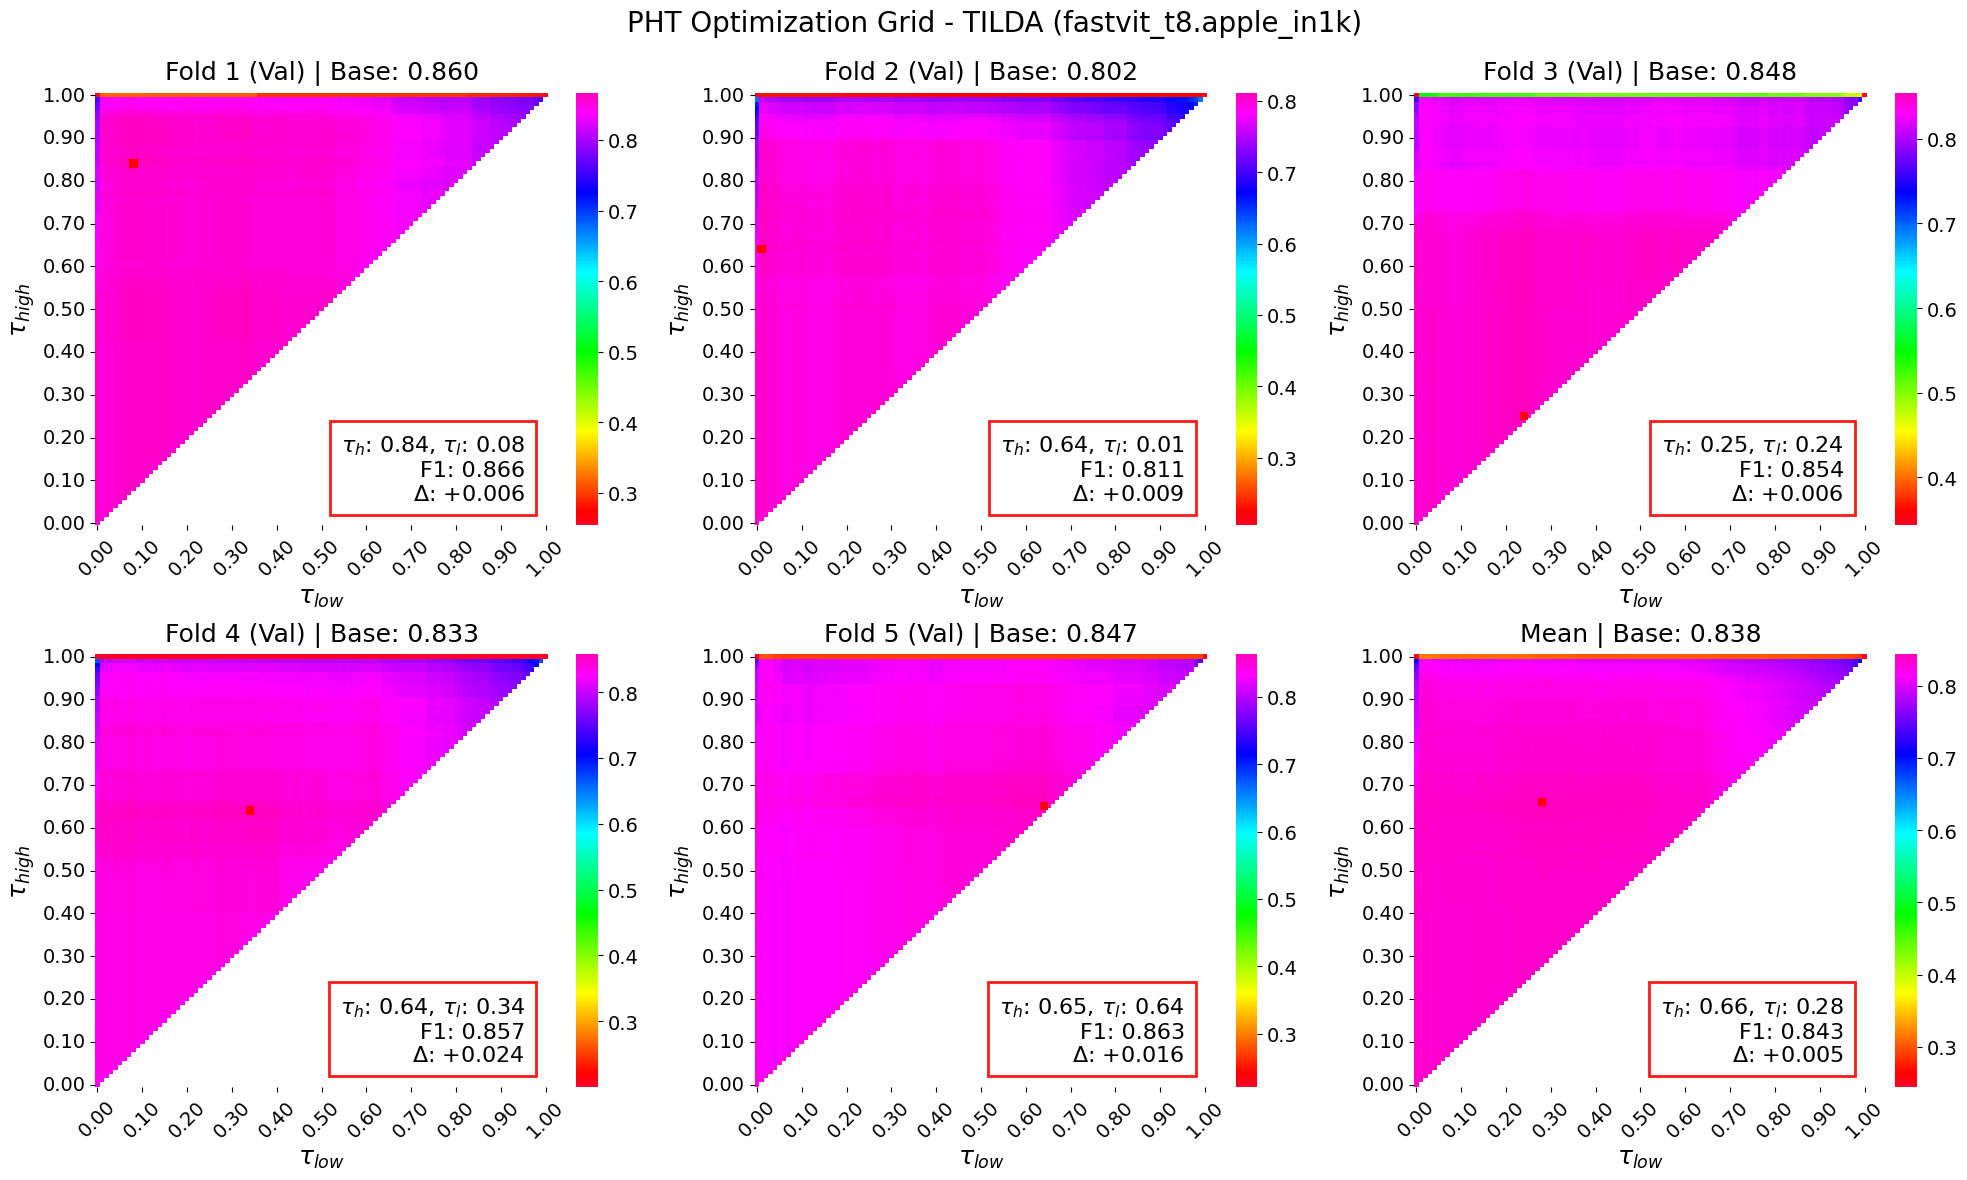

In [13]:
METHOD="pht" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)

[2026-08-15 02:40:04] [INFO] Processing Fold 1/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 02:40:32] [INFO] Detected target classes: 5
[2026-08-15 02:40:32] [INFO] Fold 1 Raw CNN Macro F1: 0.8601


[2026-08-15 02:44:08] [INFO] Fold 1 Peak SIMANTIRIS Macro F1: 0.2212 (Delta: -0.6389) at t1=0.16, t2=0.00


[2026-08-15 02:44:09] [INFO] Processing Fold 2/5 (SIMANTIRIS)


...

[2026-08-15 02:56:27] [INFO] Processing Fold 5/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 02:56:56] [INFO] Fold 5 Raw CNN Macro F1: 0.8472


[2026-08-15 03:00:33] [INFO] Fold 5 Peak SIMANTIRIS Macro F1: 0.2004 (Delta: -0.6468) at t1=0.05, t2=0.00


[2026-08-15 03:00:33] [INFO] SIMANTIRIS Grid Search Complete (5 Classes)
[2026-08-15 03:00:33] [INFO] Optimal Global Thresholds -> t1: 0.040 | t2: 0.000
[2026-08-15 03:00:33] [INFO] Consensus Baseline Macro F1: 0.8380
[2026-08-15 03:00:33] [INFO] Consensus SIMANTIRIS Macro F1: 0.2158
[2026-08-15 03:00:33] [INFO] Net Macro F1 Gain (Delta):   -0.6223
[2026-08-15 03:00:33] [INFO] Landscape Congruence (LCI):  0.3035 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 03:00:33] [INFO] Threshold Dispersion (TDI):  0.1220 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/simantiris_search_TILDA_64_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


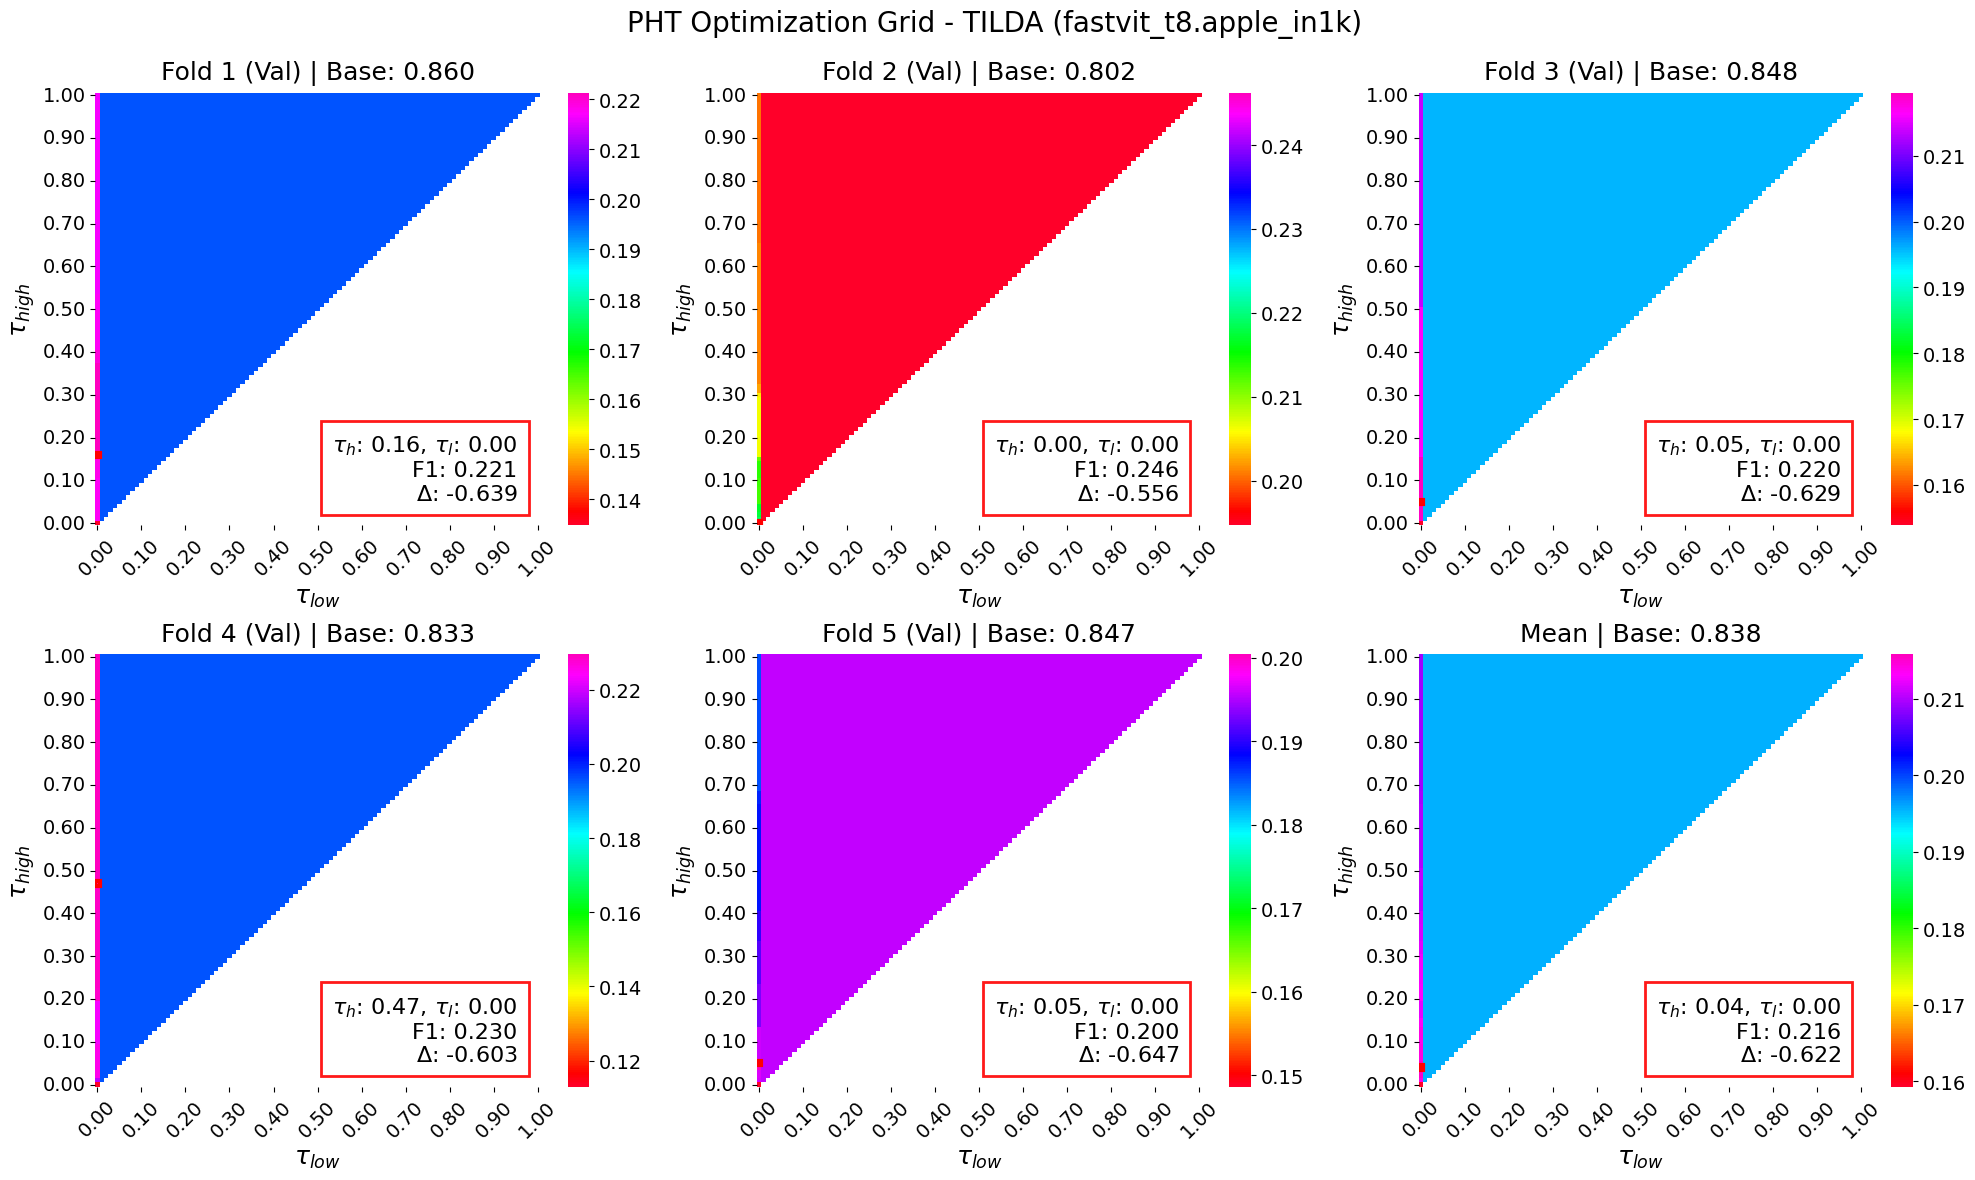

In [14]:
METHOD="simantiris" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
    struct_elem=SE_DISK_7x7
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)

[2026-08-15 03:00:42] [INFO] Processing Fold 1/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 03:01:11] [INFO] Detected target classes: 5
[2026-08-15 03:01:11] [INFO] Fold 1 Raw CNN Macro F1: 0.8601


[2026-08-15 03:04:22] [INFO] Fold 1 Peak SIMANTIRIS Macro F1: 0.2406 (Delta: -0.6195) at t1=0.01, t2=0.01


[2026-08-15 03:04:22] [INFO] Processing Fold 2/5 (SIMANTIRIS)


...

[2026-08-15 03:15:26] [INFO] Processing Fold 5/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                          

[2026-08-15 03:15:54] [INFO] Fold 5 Raw CNN Macro F1: 0.8472


[2026-08-15 03:19:03] [INFO] Fold 5 Peak SIMANTIRIS Macro F1: 0.2341 (Delta: -0.6131) at t1=0.01, t2=0.01


[2026-08-15 03:19:04] [INFO] SIMANTIRIS Grid Search Complete (5 Classes)
[2026-08-15 03:19:04] [INFO] Optimal Global Thresholds -> t1: 0.020 | t2: 0.010
[2026-08-15 03:19:04] [INFO] Consensus Baseline Macro F1: 0.8380
[2026-08-15 03:19:04] [INFO] Consensus SIMANTIRIS Macro F1: 0.2474
[2026-08-15 03:19:04] [INFO] Net Macro F1 Gain (Delta):   -0.5906
[2026-08-15 03:19:04] [INFO] Landscape Congruence (LCI):  0.4897 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 03:19:04] [INFO] Threshold Dispersion (TDI):  0.0000 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/simantiris_search_TILDA_64_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


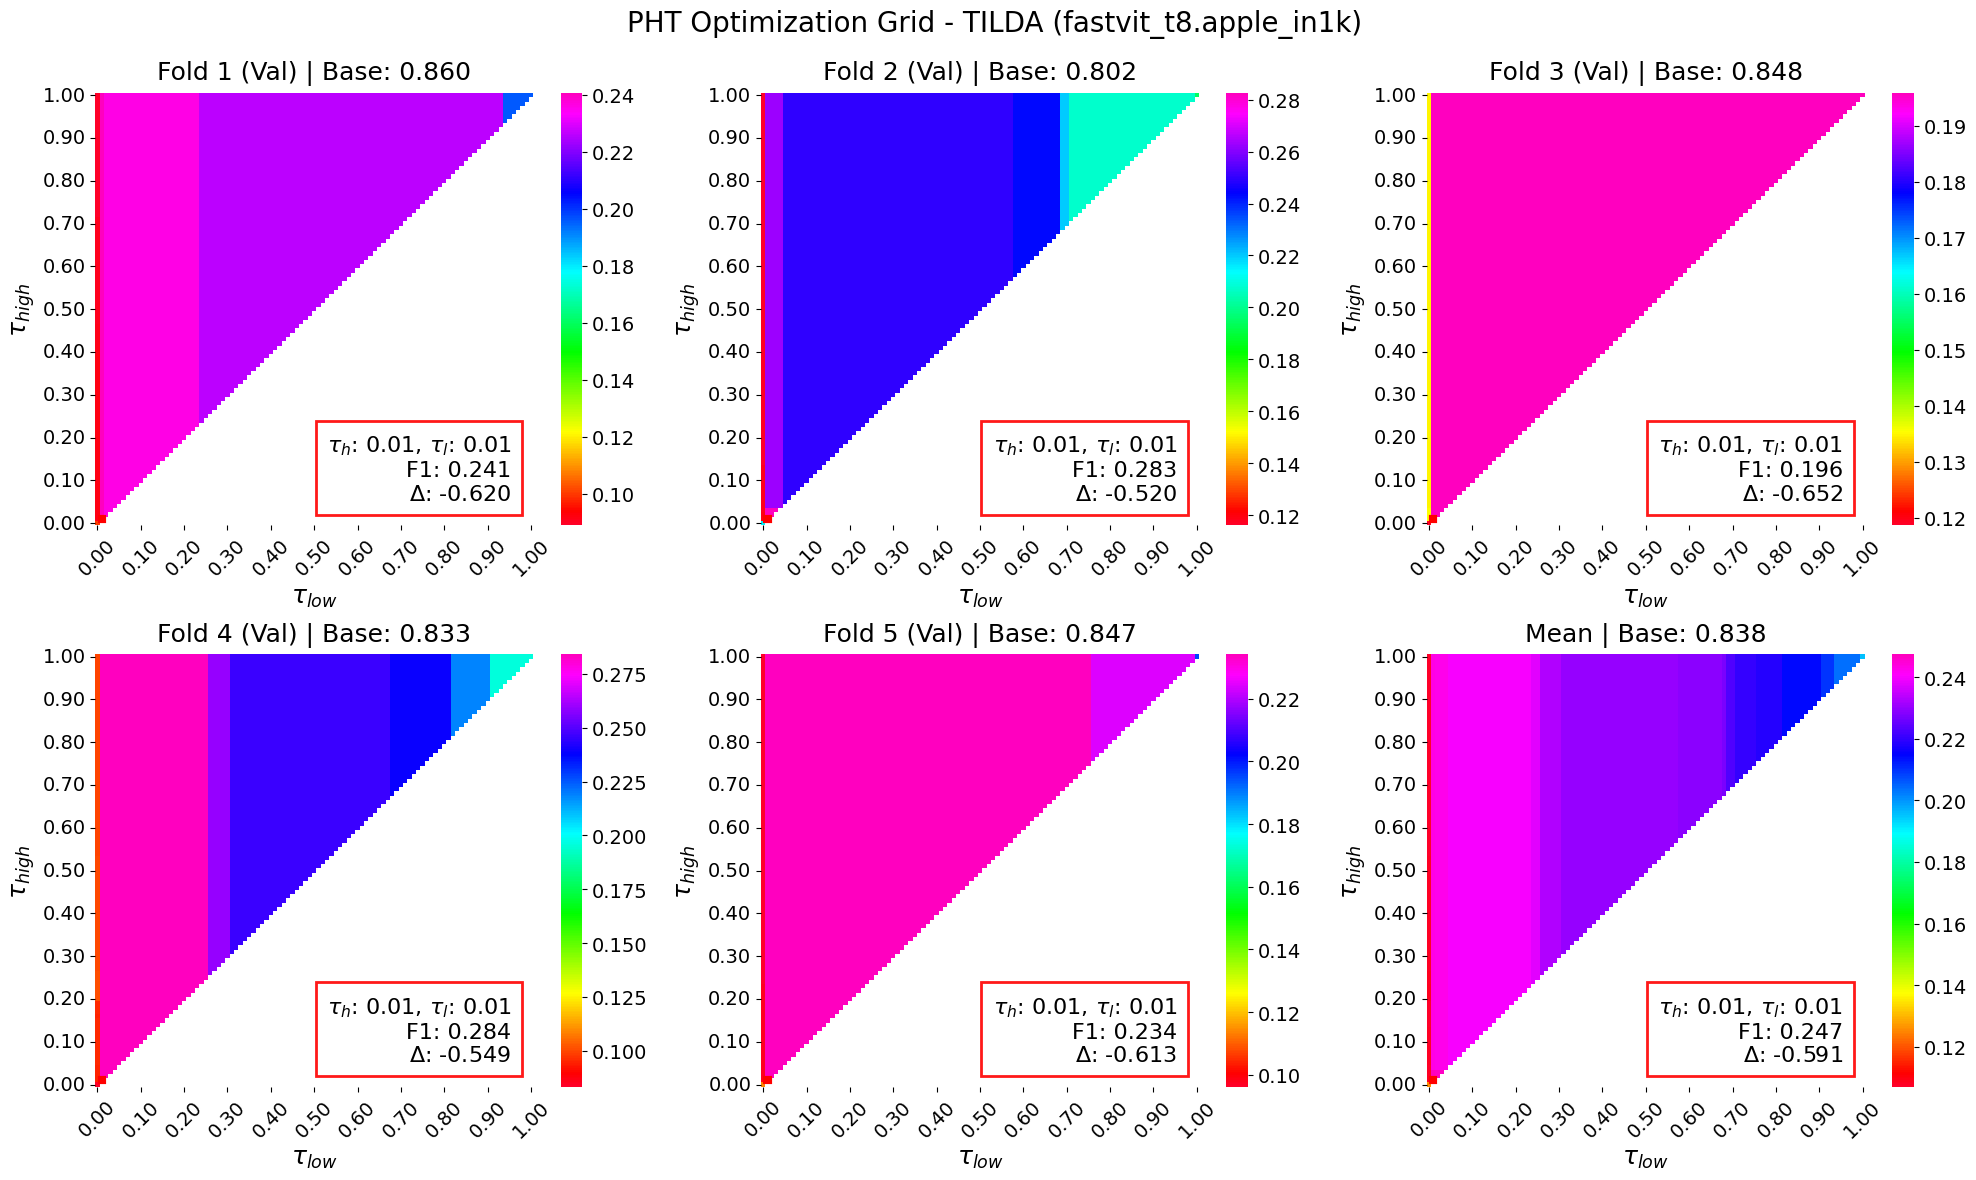

In [15]:
METHOD="simantiris" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
    struct_elem=SE_DISK_3x3
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)

# HKU32_FVIT_BASE

In [16]:
DATASET_NAME="HKU"
PATCH_SIZE=32
TIMM_MODEL_NAME="fastvit_t8.apple_in1k"
EXP_NAME="baseline"
MODEL_PATH="/kaggle/input/datasets/labsys443/hku32-fvit-base/experiments/HKU_32_baseline_fastvit_t8.apple_in1k"
JSON_SPLITS = '/kaggle/input/datasets/labsys443/tilda-hku-patched/metadata/hku_splits_seed42.json'

[2026-08-15 03:19:20] [INFO] Processing Fold 1/5 (PHT)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 03:19:26] [INFO] Detected target classes: 7
[2026-08-15 03:19:26] [INFO] Fold 1 Raw CNN Macro F1: 0.8211


[2026-08-15 03:25:38] [INFO] Fold 1 Peak PHT Macro F1: 0.8771 (Delta: +0.0560) at t1=0.02, t2=0.01


[2026-08-15 03:25:38] [INFO] Processing Fold 2/5 (PHT)


...

[2026-08-15 03:44:00] [INFO] Processing Fold 5/5 (PHT)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 03:44:06] [INFO] Fold 5 Raw CNN Macro F1: 0.8979


[2026-08-15 03:50:28] [INFO] Fold 5 Peak PHT Macro F1: 0.8979 (Delta: +0.0000) at t1=0.00, t2=0.00


[2026-08-15 03:50:28] [INFO] PHT Grid Search Complete (7 Classes)
[2026-08-15 03:50:28] [INFO] Optimal Global Thresholds -> t1: 0.320 | t2: 0.270
[2026-08-15 03:50:28] [INFO] Consensus Baseline Macro F1: 0.7855
[2026-08-15 03:50:28] [INFO] Consensus PHT Macro F1: 0.7867
[2026-08-15 03:50:28] [INFO] Net Macro F1 Gain (Delta):   +0.0011
[2026-08-15 03:50:28] [INFO] Landscape Congruence (LCI):  0.4481 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 03:50:28] [INFO] Threshold Dispersion (TDI):  0.1252 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/pht_search_HKU_32_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


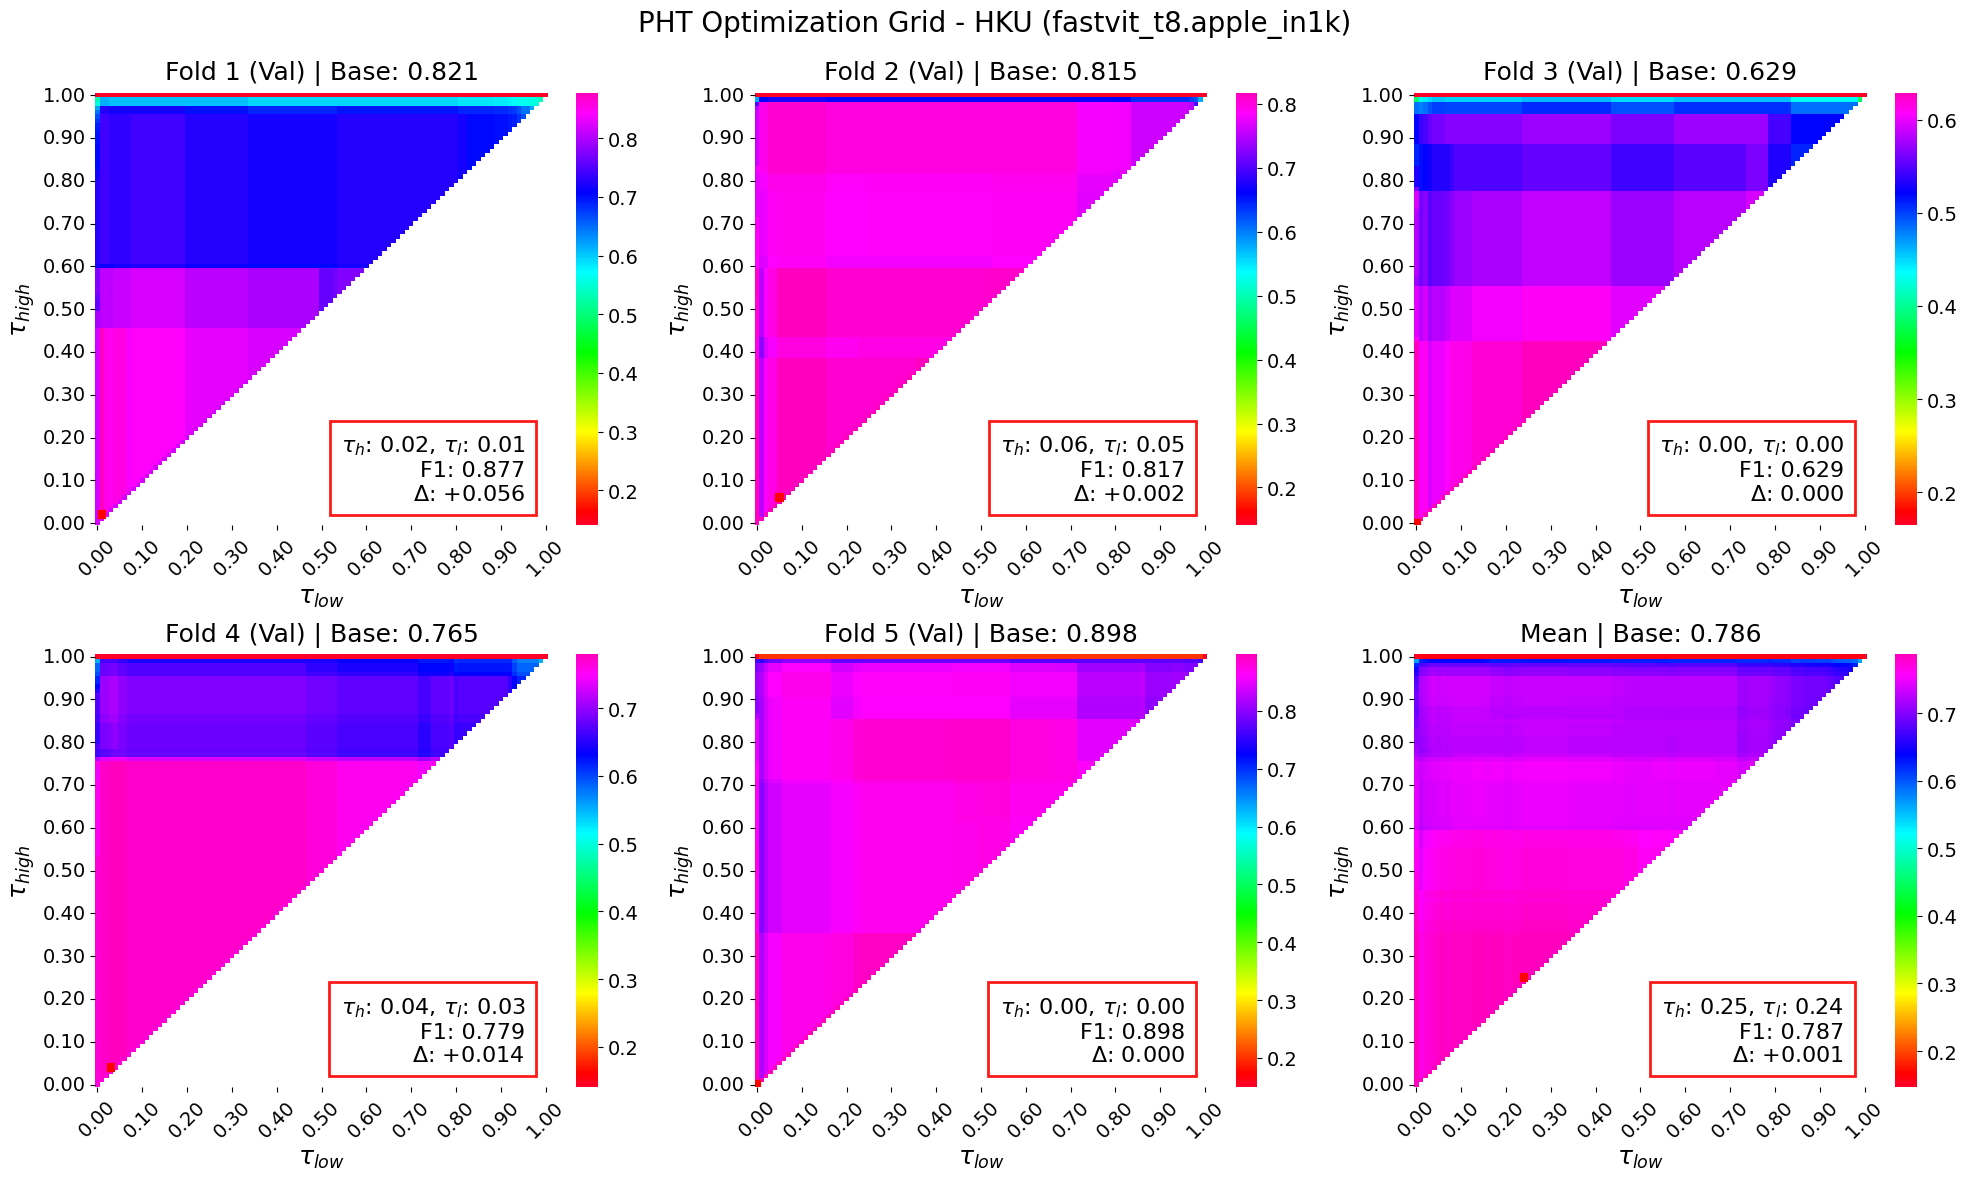

In [17]:
METHOD="pht" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)

[2026-08-15 03:50:37] [INFO] Processing Fold 1/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 03:50:43] [INFO] Detected target classes: 7
[2026-08-15 03:50:43] [INFO] Fold 1 Raw CNN Macro F1: 0.8211


[2026-08-15 03:52:45] [INFO] Fold 1 Peak SIMANTIRIS Macro F1: 0.2261 (Delta: -0.5951) at t1=0.00, t2=0.00


[2026-08-15 03:52:45] [INFO] Processing Fold 2/5 (SIMANTIRIS)


...

[2026-08-15 03:58:57] [INFO] Processing Fold 5/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 03:59:03] [INFO] Fold 5 Raw CNN Macro F1: 0.8979


[2026-08-15 04:00:58] [INFO] Fold 5 Peak SIMANTIRIS Macro F1: 0.2325 (Delta: -0.6653) at t1=0.00, t2=0.00


[2026-08-15 04:00:58] [INFO] SIMANTIRIS Grid Search Complete (7 Classes)
[2026-08-15 04:00:58] [INFO] Optimal Global Thresholds -> t1: 0.000 | t2: 0.000
[2026-08-15 04:00:58] [INFO] Consensus Baseline Macro F1: 0.7855
[2026-08-15 04:00:58] [INFO] Consensus SIMANTIRIS Macro F1: 0.1981
[2026-08-15 04:00:58] [INFO] Net Macro F1 Gain (Delta):   -0.5874
[2026-08-15 04:00:58] [INFO] Landscape Congruence (LCI):  0.9919 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 04:00:58] [INFO] Threshold Dispersion (TDI):  0.0060 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/simantiris_search_HKU_32_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


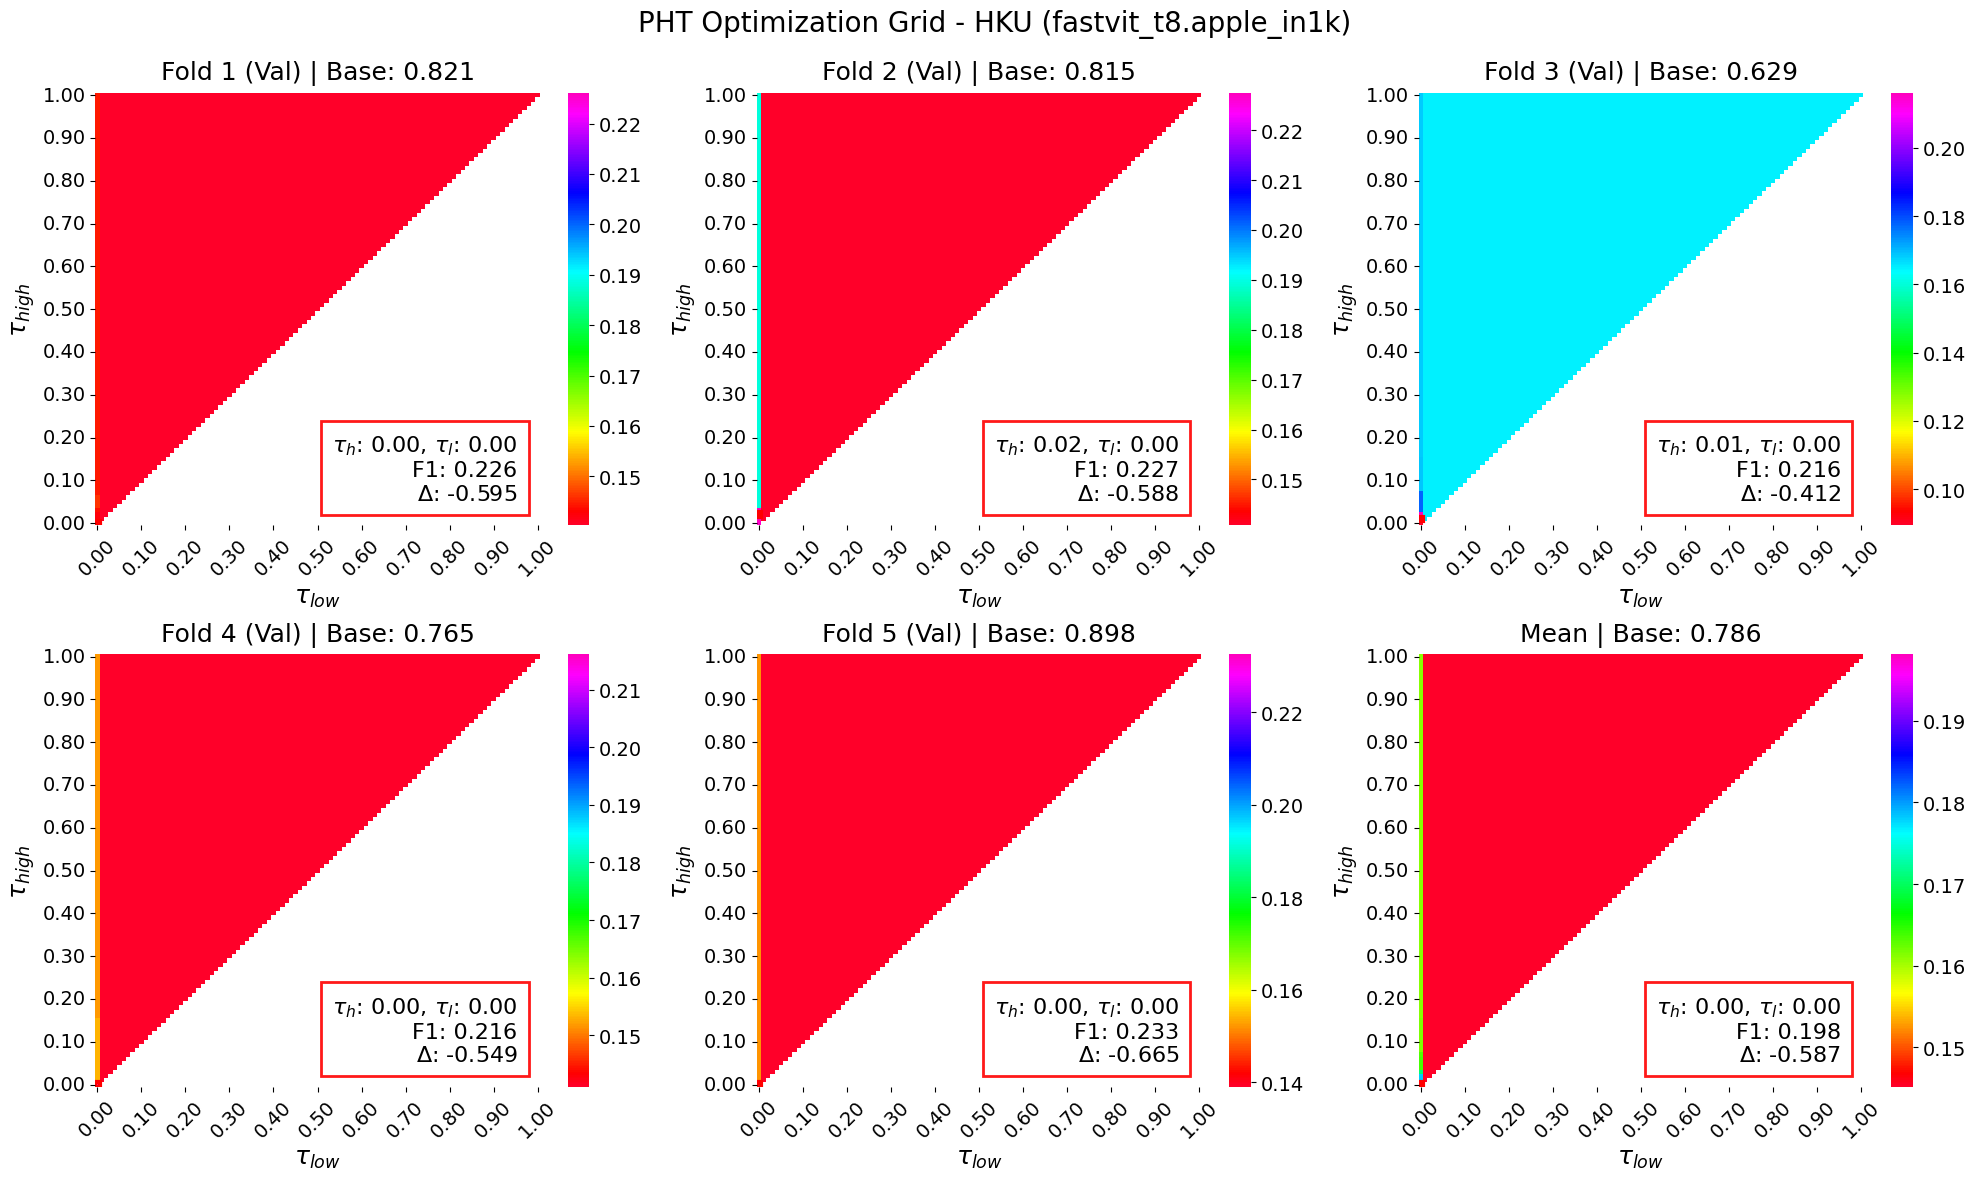

In [18]:
METHOD="simantiris" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
    struct_elem=SE_DISK_7x7
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)

[2026-08-15 04:01:08] [INFO] Processing Fold 1/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 04:01:14] [INFO] Detected target classes: 7
[2026-08-15 04:01:14] [INFO] Fold 1 Raw CNN Macro F1: 0.8211


[2026-08-15 04:02:56] [INFO] Fold 1 Peak SIMANTIRIS Macro F1: 0.1833 (Delta: -0.6379) at t1=0.00, t2=0.00


[2026-08-15 04:02:57] [INFO] Processing Fold 2/5 (SIMANTIRIS)


...

[2026-08-15 04:08:13] [INFO] Processing Fold 5/5 (SIMANTIRIS)


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['class_weights_tensor']
                                                                        

[2026-08-15 04:08:19] [INFO] Fold 5 Raw CNN Macro F1: 0.8979


[2026-08-15 04:09:59] [INFO] Fold 5 Peak SIMANTIRIS Macro F1: 0.2726 (Delta: -0.6253) at t1=0.01, t2=0.01


[2026-08-15 04:10:01] [INFO] SIMANTIRIS Grid Search Complete (7 Classes)
[2026-08-15 04:10:01] [INFO] Optimal Global Thresholds -> t1: 0.680 | t2: 0.330
[2026-08-15 04:10:01] [INFO] Consensus Baseline Macro F1: 0.7855
[2026-08-15 04:10:01] [INFO] Consensus SIMANTIRIS Macro F1: 0.1719
[2026-08-15 04:10:01] [INFO] Net Macro F1 Gain (Delta):   -0.6137
[2026-08-15 04:10:01] [INFO] Landscape Congruence (LCI):  0.1567 (Spearman Rank Corr: 1.0 = identical topology, <0.5 = unstable)
[2026-08-15 04:10:01] [INFO] Threshold Dispersion (TDI):  0.4535 (Avg coordinate distance to consensus, lower is better)
[INFO] Plot exported successfully to: /kaggle/working/experiments/simantiris_search_HKU_32_baseline_fastvit_t8.apple_in1k/pht_grid_search_results.png


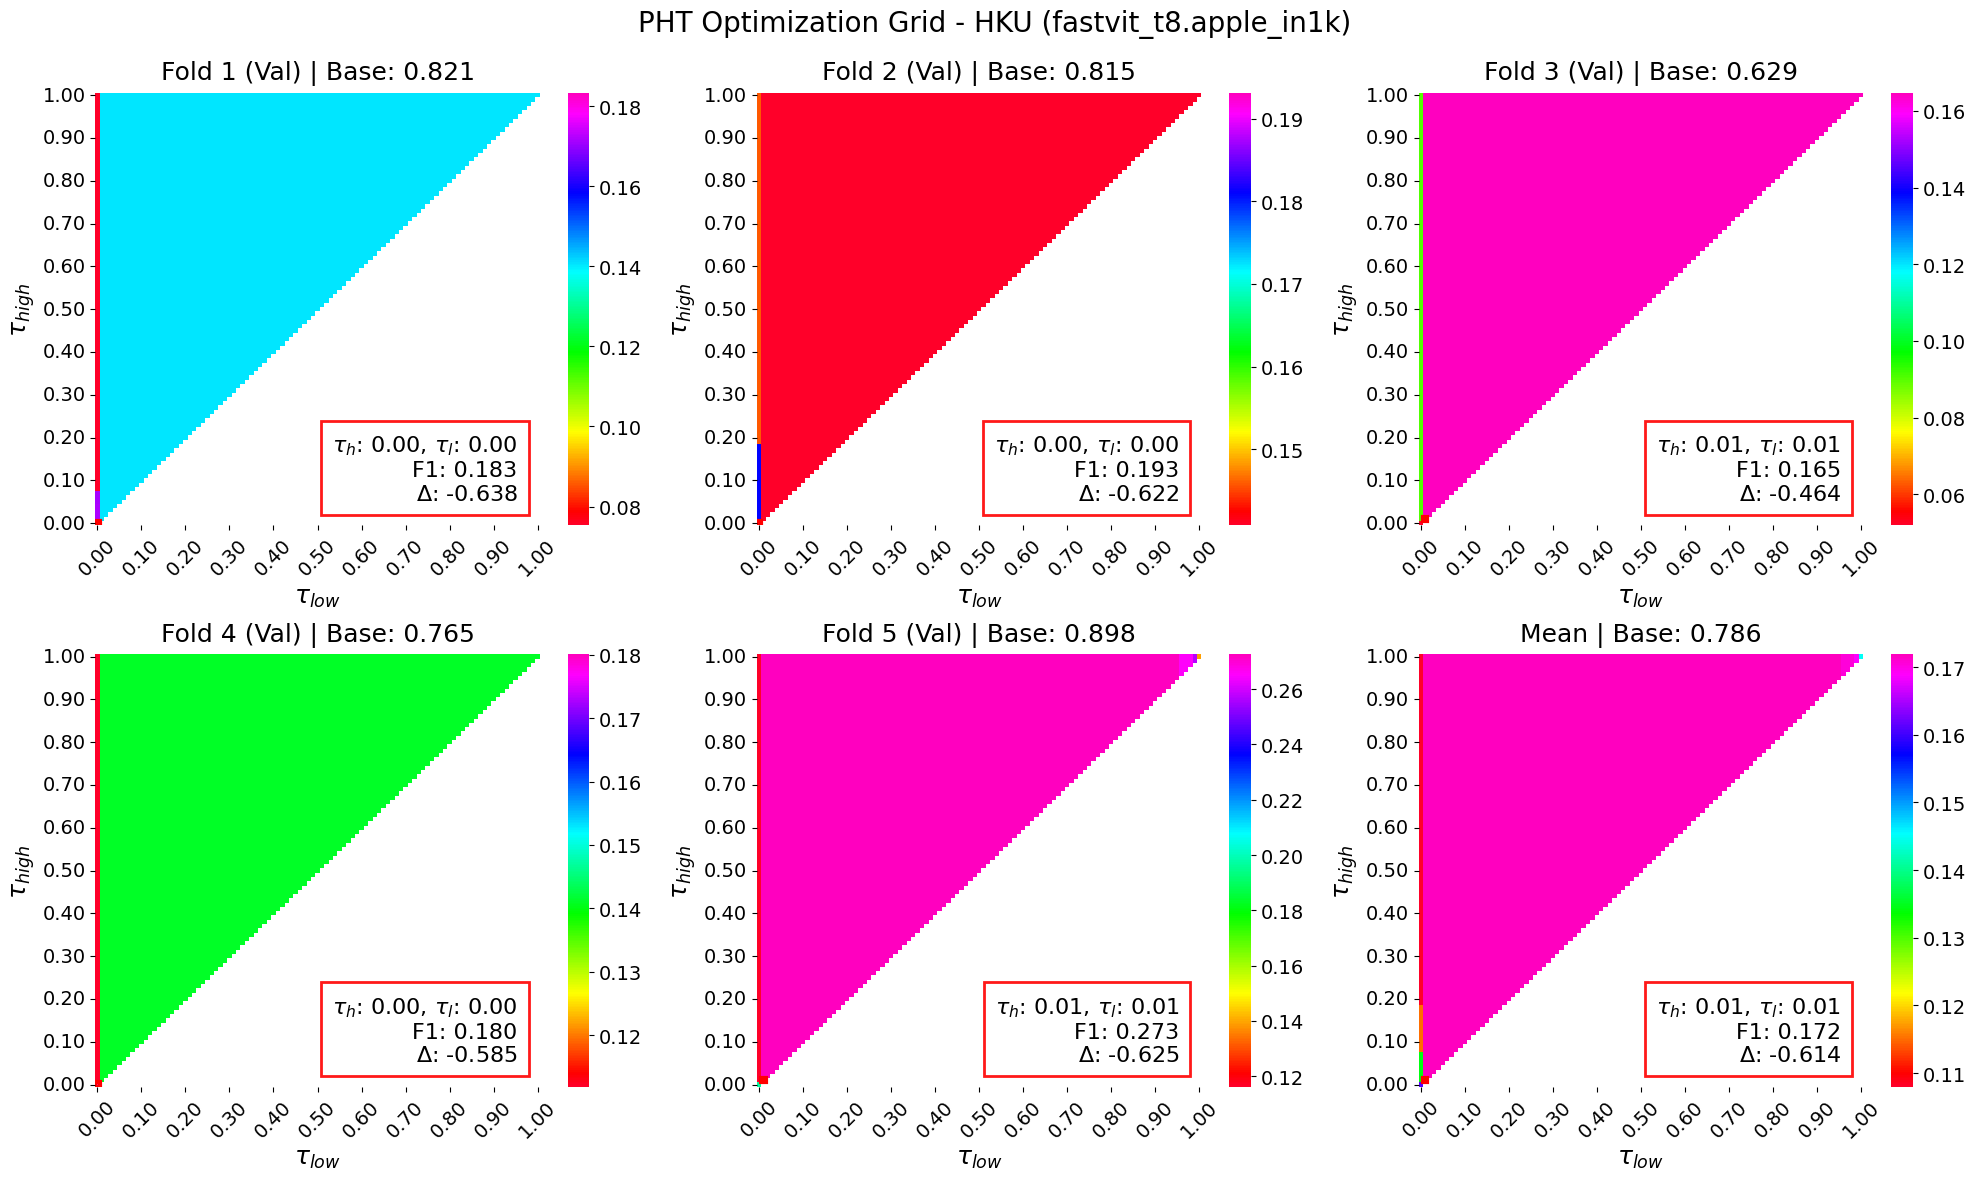

In [19]:
METHOD="simantiris" # pht or simantiris

pht_results = run_postprocessing_grid_search(
    method=METHOD,
    dataset_name=DATASET_NAME,
    patch_size=PATCH_SIZE,
    timm_model_name=TIMM_MODEL_NAME,
    tau_range=TAU_RANGE,
    batch_size=256,
    data_base_path="/kaggle/input/datasets/labsys443/tilda-hku-patched",
    json_split_path=JSON_SPLITS,
    model_base_path=MODEL_PATH,
    device="cuda",
    struct_elem=SE_DISK_3x3
)

plot_pht_grid_results(
    results=pht_results,
    dataset_name=DATASET_NAME,
    model_name=TIMM_MODEL_NAME,
    cmap="gist_rainbow"
)